In [8]:
# Step 0: Install Required Libraries
!pip install qiskit matplotlib pylatexenc --quiet

In [9]:
# STEP 1: IMPORT LIBRARIES
# Import Qiskit core modules for creating circuits and state analysis
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector

# Display is used to show circuit diagrams nicely inside Jupyter Notebook
from IPython.display import display

# Matplotlib for plotting visual results
import matplotlib.pyplot as plt

# Random module used to simulate noise (bit flips)
import random

=== Encoding Circuit ===


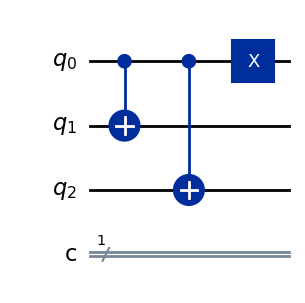

In [10]:
# STEP 2: ENCODING CIRCUIT (3-QUBIT BIT-FLIP CODE)
# This circuit encodes one logical qubit into three physical qubits
# The redundancy helps detect and correct single bit-flip errors

# Create a quantum circuit with 3 qubits and 1 classical bit
qc_encode = QuantumCircuit(3, 1)

# Apply CNOT gates to copy the state of qubit 0 into qubits 1 and 2
qc_encode.cx(0, 1)
qc_encode.cx(0, 2)

# Apply an X gate on qubit 0 to encode the |1> logical state
qc_encode.x(0)

# Display the encoding circuit visually
print("=== Encoding Circuit ===")
display(qc_encode.draw('mpl'))

=== Bloch Vector Before Noise ===


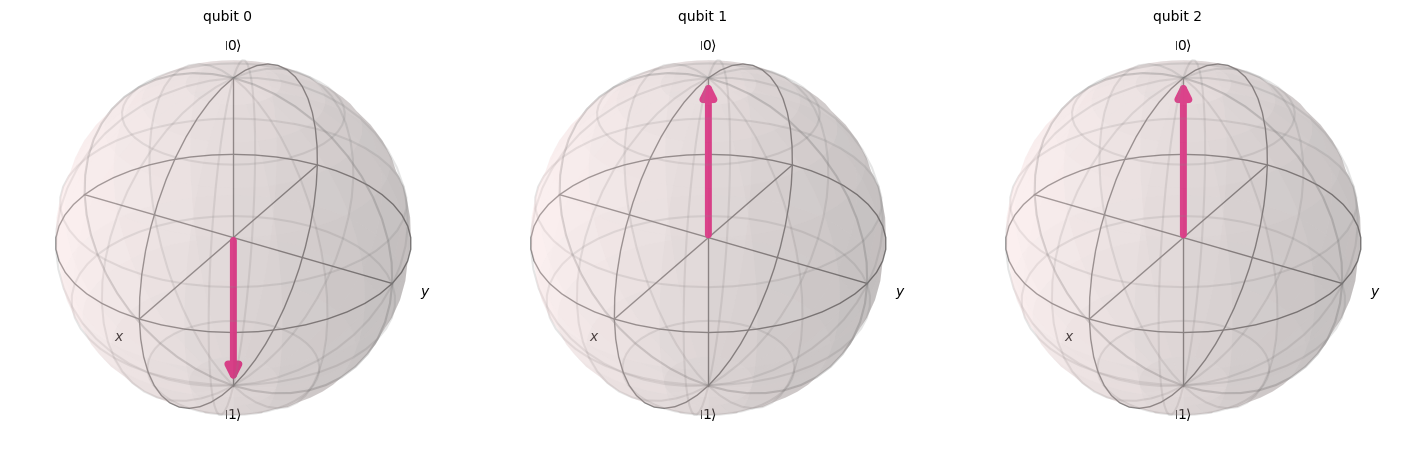

In [12]:
# STEP 3: BLOCH VECTOR BEFORE NOISE
# This shows the quantum state before any noise is applied
# Bloch sphere helps visualize the orientation of a qubit's state
state_before = Statevector.from_instruction(qc_encode)
print("=== Bloch Vector Before Noise ===")
plot_bloch_multivector(state_before)

In [13]:
# STEP 4: NOISE SIMULATION (BIT-FLIP NOISE)
# Define a function to apply bit-flip noise with probability p
# Each qubit may flip (0 -> 1 or 1 -> 0) randomly based on p

def apply_bit_flip(qubits, p=0.3):
    """Apply bit-flip noise to a list of qubits with probability p."""
    # Iterate through each qubit; flip it if random number < p
    return [q ^ 1 if random.random() < p else q for q in qubits]

=== Decoding Circuit ===


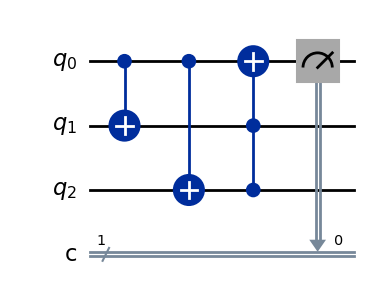

In [14]:
# STEP 5: DECODING CIRCUIT (MAJORITY VOTE LOGIC)
# This circuit will perform majority voting logic in quantum form
# The goal is to recover the original bit even if one of them flipped

# Create a new quantum circuit for decoding with 3 qubits and 1 classical bit
qc_decode = QuantumCircuit(3, 1)

# Apply CNOTs and a Toffoli gate to check for agreement among qubits
qc_decode.cx(0, 1)
qc_decode.cx(0, 2)
qc_decode.ccx(1, 2, 0)   # Majority logic gate (Toffoli)

# Measure the result of the first qubit (decoded value)
qc_decode.measure(0, 0)

# Display the decoding circuit
print("=== Decoding Circuit ===")
display(qc_decode.draw('mpl'))

In [15]:
# STEP 6: ERROR CORRECTION SIMULATION (CLASSICAL LOGIC)
# In a real quantum computer, noise happens physically.
# Here, we simulate that process using random bit flips and classical logic.

def decode_majority(qubits):
    """Decode using majority vote (returns 1 if two or more qubits are 1)."""
    return 1 if qubits.count(1) >= 2 else 0


def simulate_bit_flip_correction(trials=1024):
    """
    Run multiple trials to simulate:
    1. Encoding logical |1> as [1, 1, 1]
    2. Applying random bit flips
    3. Decoding using majority logic
    Returns dictionary of counts {'0': X, '1': Y}
    """
    results = {'0': 0, '1': 0}

    for _ in range(trials):
        # Step 1: Encode logical |1> as three physical qubits
        qubits = [1, 1, 1]

        # Step 2: Apply bit-flip noise (each qubit has 30% chance to flip)
        qubits = apply_bit_flip(qubits, p=0.3)

        # Step 3: Decode using majority voting logic
        result = decode_majority(qubits)

        # Step 4: Count the number of times we get 0 or 1
        results[str(result)] += 1

    return results


# Run the simulation for 1024 trials
counts = simulate_bit_flip_correction(1024)

=== Measurement Results After Error Correction ===
{'0': 237, '1': 787}


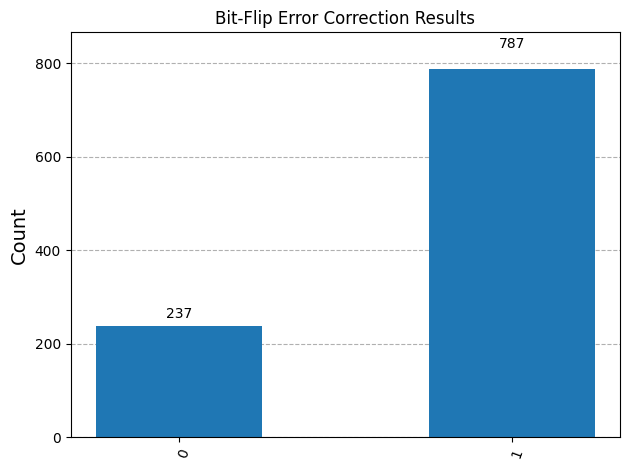

In [19]:
# STEP 7: DISPLAY FINAL RESULTS AND HISTOGRAM
# This shows how many times the corrected result was 0 or 1
# The histogram helps visualize success of error correction

print("=== Measurement Results After Error Correction ===")
print(counts)

# Plot the histogram for better visualization
plot_histogram(counts, title="Bit-Flip Error Correction Results")